   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2 

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444 

          0         1
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835 



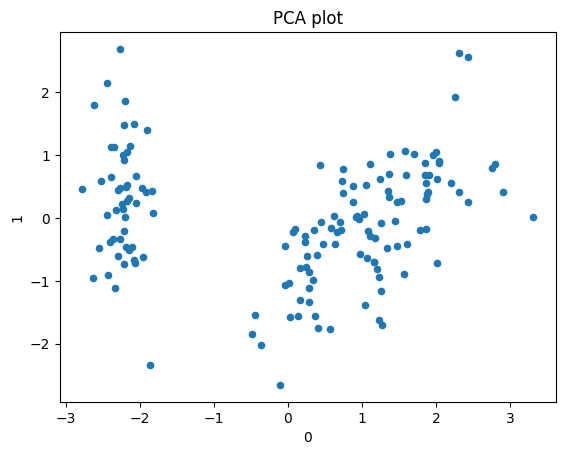

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../data/iris.csv")
df = df.drop('Species', axis = 1)
print(df.head(), '\n')

scaler = StandardScaler()
result = scaler.fit_transform(df)
df_scaled = pd.DataFrame(result, columns = df.columns)
print(df_scaled.head(), '\n')

pca = PCA(n_components = 2)
transform = pca.fit_transform(df_scaled)
transform = pd.DataFrame(transform)
print(transform.head(), '\n')

transform.plot.scatter(x = 0, y = 1, title = 'PCA plot')

plt.show()

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2 

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444 

[[ 1.13597027  0.08842168  0.99615451  1.01752612]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [-0.05021989 -0.88337647  0.34773781  0.2815273 ]] 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2

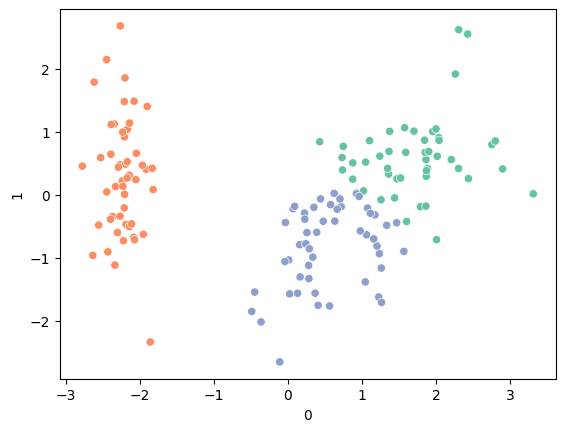

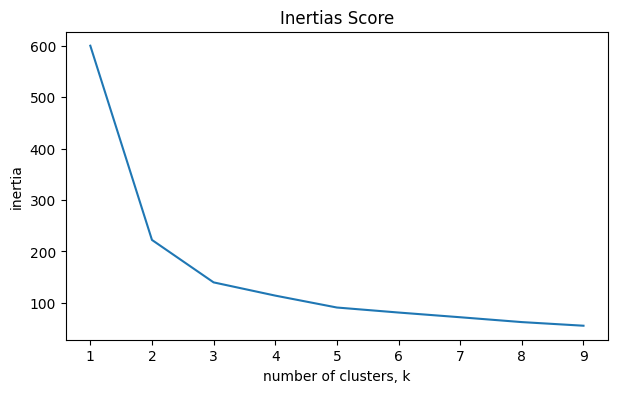

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/iris.csv")
df = df.drop('Species', axis = 1)
print(df.head(), '\n')

scaler = StandardScaler()
result = scaler.fit_transform(df)
df_scaled = pd.DataFrame(result, columns = df.columns)
print(df_scaled.head(), '\n')

# 군집화
model = KMeans(n_clusters = 3, n_init = 10, random_state = 123) # n_clusters : 군집개수, n_init : 클러스터링 횟수
model.fit(df_scaled)

# 군집화 결과확인
print(model.cluster_centers_, '\n') # 군집 중심점 좌표
print(model.labels_, '\n') # 각 행의 군집 번호
print(model.inertia_, '\n') # 군집 평가 점수

# 차원 축소
pca = PCA(n_components = 2)
transform = pca.fit_transform(df_scaled)
transform = pd.DataFrame(transform)
transform['cluster'] = model.labels_
print(transform.head(), '\n')


sns.scatterplot(data = transform,
                x = 0,  
                y = 1,
                hue = 'cluster',
                palette = 'Set2',
                legend = False)

plt.show()

ks = range(1, 10)
inertias = pd.Series([])

for k in ks:
    model = KMeans(n_clusters = k, n_init = 10, random_state = 123)
    model.fit(df_scaled)
    inertias.loc[k] = model.inertia_

plt.figure(figsize = (7, 4))
inertias.plot.line(title = 'Inertias Score',
                   xlabel = 'number of clusters, k',
                   ylabel = 'inertia')

plt.show()

In [2]:
#12-4
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC

df = pd.read_csv("../data/PimaIndiansDiabetes.csv")
print(df.head(), '\n')
print(df.groupby('diabetes')['diabetes'].count(), '\n')

X = df.drop('diabetes', axis = 1)
y = df['diabetes']

#데이터 표준화
scaler = StandardScaler()
scaler.fit(X)
result = scaler.transform(X)
X_scaled = pd.DataFrame(result, columns = X.columns)
print(X_scaled.head(), '\n')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 12, stratify = y) 
# stratify = y : 클래스별 비율을 유지하며 훈련용 데이터와 테스트용 데이터를 나눔, default는 n

knn = KNC(n_neighbors = 3)
knn.fit(X_train, y_train)

print(knn.score(X_test, y_test), '\n')

data = pd.DataFrame([[8, 182, 64, 0, 0, 23, 0.67, 32]], columns = X_test.columns)
data = scaler.transform(data)
patient = pd.DataFrame(data, columns = X_test.columns)
print(patient, '\n')

pred = knn.predict(patient)
print(pred, '\n')

pred = knn.predict(X_test)
print(pred)

   pregnant  glucose  pressure  triceps  insulin  mass  pedigree  age diabetes
0         6      148        72       35        0  33.6     0.627   50      pos
1         1       85        66       29        0  26.6     0.351   31      neg
2         8      183        64        0        0  23.3     0.672   32      pos
3         1       89        66       23       94  28.1     0.167   21      neg
4         0      137        40       35      168  43.1     2.288   33      pos 

diabetes
neg    500
pos    268
Name: diabetes, dtype: int64 

   pregnant   glucose  pressure   triceps   insulin      mass  pedigree  \
0  0.639947  0.848324  0.149641  0.907270 -0.692891  0.204013  0.468492   
1 -0.844885 -1.123396 -0.160546  0.530902 -0.692891 -0.684422 -0.365061   
2  1.233880  1.943724 -0.263941 -1.288212 -0.692891 -1.103255  0.604397   
3 -0.844885 -0.998208 -0.160546  0.154533  0.123302 -0.494043 -0.920763   
4 -1.141852  0.504055 -1.504687  0.907270  0.765836  1.409746  5.484909   

        age

                   job  education  income  women  prestige  census  type
0   gov.administrators      13.11   12351  11.16      68.8    1113  prof
1     general.managers      12.26   25879   4.02      69.1    1130  prof
2          accountants      12.77    9271  15.70      63.4    1171  prof
3  purchasing.officers      11.42    8865   9.11      56.8    1175  prof
4             chemists      14.62    8403  11.68      73.5    2111  prof 

[173.60049469 -52.42607129 146.75658987] 

-291.5527059562255 

1787.3166863311678 



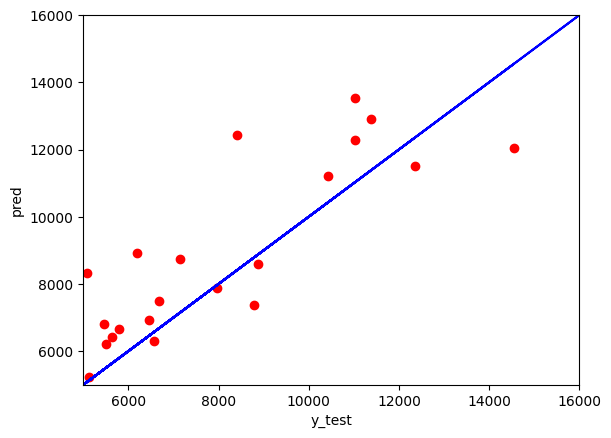

   education  women  prestige
0         12     10        80 

[13007.9197067]


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

df = pd.read_csv("../data/prestige.csv")
print(df.head(), '\n')

X = df[['education', 'women', 'prestige']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123) 

# 모델 생성
model = LR()
model.fit(X_train, y_train)

# 회귀식 확인
print(model.coef_, '\n')
print(model.intercept_, '\n')

# 모델 평가 : MAE (평균 절대 오차(MAE, Mean Absolute Error))
pred = model.predict(X_test)
print(MAE(y_test, pred), '\n')

plt.scatter(y_test, pred, color = 'red')
plt.xlim([5000, 16000])
plt.ylim([5000, 16000])
plt.xlabel('y_test')
plt.ylabel('pred')
plt.plot(y_test, y_test, color='blue') # 대각선 그리기
plt.show()

# 모델 활용
job = pd.DataFrame([[12, 10, 80]], columns = X_test.columns)
print(job, '\n')

pred = model.predict(job)
print(pred)